# Telecom Churn — Análise Exploratória

**Objetivo deste notebook:** Quantificar o problema, identificar os segmentos de maior risco e estimar o impacto de intervenções concretas.

**Estrutura (20 min de apresentação):**
| # | Seção | Pergunta respondida |
|---|---|---|
| 1 | Escala | Quanto custa o churn atual? |
| 2 | Sobrevivência | Quando saem, e isso viola o payback? |
| 3 | Perfil | Quem sai? |
| 4 | Feature Importance (SHAP) | O que *realmente* importa? |
| 5 | Segmento crítico | Onde se concentra o problema? |
| 6 | Alavancas | O que fazer, em qual ordem? |

- Estimativas de impacto das alavancas são **associativas**, não causais. Todas requerem A/B test para validação.

## Setup

In [1]:
!pip install lifelines
!pip install ydata-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0d6a49fb8ad451a48e777d4754112c5f4d7e53e8be48df1068c59982902688ed
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency
from lifelines import KaplanMeierFitter
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
import shap
from ydata_profiling import ProfileReport

import warnings; warnings.filterwarnings('ignore')

In [5]:
COR_CHURN  = '#E63946'
COR_RETIDO = '#2A9D8F'
COR_WARN   = '#F4A261'
CMAP_RISCO = LinearSegmentedColormap.from_list("risco", [COR_RETIDO, COR_WARN, COR_CHURN])

plt.rcParams.update({
    'font.family'     : 'sans-serif',
    'font.sans-serif' : ['Arial', 'DejaVu Sans'],
    'text.color'      : '#2b2b2b',
    'axes.labelcolor' : '#444',
    'xtick.color'     : '#444',
    'ytick.color'     : '#444',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

df = pd.read_excel('Customer-Churn.xlsx')
profile = ProfileReport(df, title="Relatório de Análise Exploratória", explorative=True)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:00<00:00, 27.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 11 registros com tenure=0 têm TotalCharges nulo → R$0 (sem fatura emitida)
assert df[df['TotalCharges'].isna()]['tenure'].eq(0).all(), "NaN em tenure > 0 — revisar!"
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['y'] = (df['Churn'] == 'Yes').astype(int)

# Tenure faixas (definição centralizada)
bins   = [0, 6, 12, 24, 48, 72]
labels = ['0–6m', '7–12m', '13–24m', '25–48m', '49–72m']
df['tenure_faixa'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# Nº de serviços adicionais (apenas clientes com internet)
svc_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']
df['n_services'] = np.where(
    df['InternetService'] == 'No',
    np.nan,
    (df[svc_cols] == 'Yes').sum(axis=1)
)
df['has_internet'] = (df['InternetService'] != 'No').astype(int)

df['n_services'] = df['n_services'].fillna(-1)

# Subsets reutilizados
df_c = df[df['y'] == 1]
df_r = df[df['y'] == 0]

print(f"Base: {len(df):,} clientes | {df['y'].sum():,} churners ({df['y'].mean():.1%}) | "
      f"{(~df['y'].astype(bool)).sum():,} retidos ({1-df['y'].mean():.1%})")
print(f"Colunas: {df.shape[1]} | Nulos remanescentes: {df.isnull().sum().sum()}")

Base: 7,043 clientes | 1,869 churners (26.5%) | 5,174 retidos (73.5%)
Colunas: 26 | Nulos remanescentes: 0


---
## 1. Escala do problema
*Quanto custa o churn atual em receita recorrente?*


In [53]:
n_total  = len(df)
n_churn  = df['y'].sum()
n_retido = n_total - n_churn
rate     = n_churn / n_total

arpu_c  = df_c['MonthlyCharges'].mean()
arpu_r  = df_r['MonthlyCharges'].mean()
gap     = arpu_c / arpu_r - 1
mrr     = df_c['MonthlyCharges'].sum()

ltv_c   = df_c['TotalCharges'].mean()   # LTV histórico — NÃO usado no modelo
ltv_r   = df_r['TotalCharges'].mean()

t_med_c = df_c['tenure'].median()
t_med_r = df_r['tenure'].median()

print("VISÃO GERAL")
print(f"  Total          : {n_total:,}")
print(f"  Churners       : {n_churn:,}  ({rate:.1%})")
print(f"  Retidos        : {n_retido:,}  ({1-rate:.1%})")
print()
print("RECEITA")
print(f"  ARPU churners  : R$ {arpu_c:.2f}/mês  (+{gap:.1%} acima dos retidos)")
print(f"  ARPU retidos   : R$ {arpu_r:.2f}/mês")
print(f"  MRR dos churners: R$ {mrr:,.0f}/mês")
print()
print("CICLO DE VIDA (tenure mediano)")
print(f"  Churners       : {t_med_c:.0f} meses")
print(f"  Retidos        : {t_med_r:.0f} meses")
print()
print("LTV ACUMULADO (TotalCharges médio — uso descritivo, não preditivo)")
print(f"  Churners       : R$ {ltv_c:,.0f}")
print(f"  Retidos        : R$ {ltv_r:,.0f}")
print(f"  Gap            : R$ {ltv_r - ltv_c:,.0f} por cliente não realizado")


VISÃO GERAL
  Total          : 7,043
  Churners       : 1,869  (26.5%)
  Retidos        : 5,174  (73.5%)

RECEITA
  ARPU churners  : R$ 74.44/mês  (+21.5% acima dos retidos)
  ARPU retidos   : R$ 61.27/mês
  MRR dos churners: R$ 139,131/mês

CICLO DE VIDA (tenure mediano)
  Churners       : 10 meses
  Retidos        : 38 meses

LTV ACUMULADO (TotalCharges médio — uso descritivo, não preditivo)
  Churners       : R$ 1,532
  Retidos        : R$ 2,550
  Gap            : R$ 1,018 por cliente não realizado


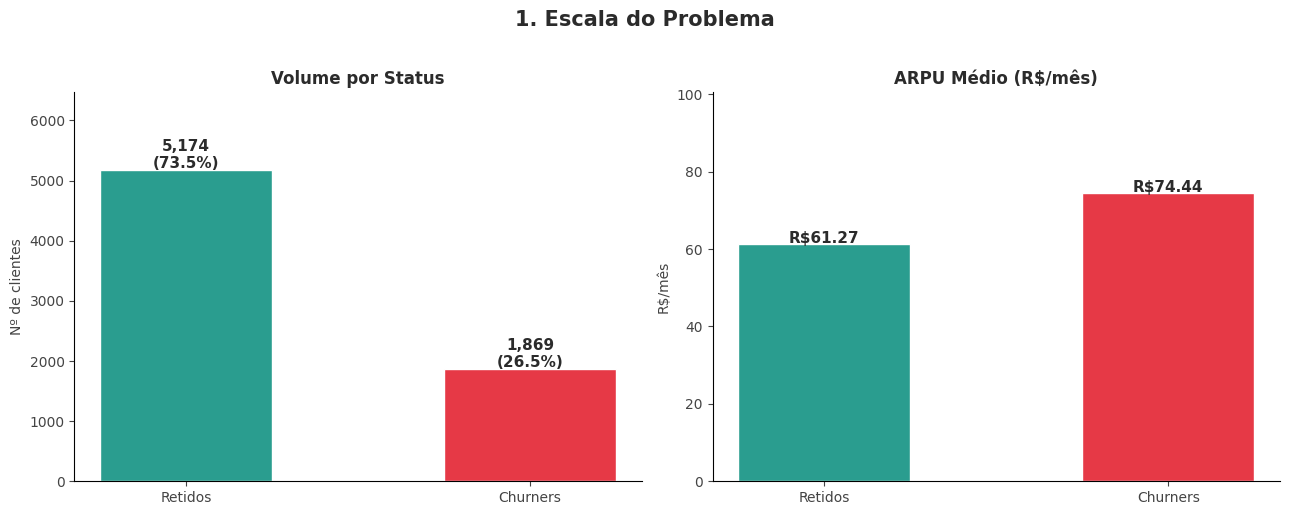

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('1. Escala do Problema', fontsize=15, fontweight='bold', y=1.02)

# 1a — Barras: volume por status
status_data = pd.DataFrame({'Status': ['Retidos', 'Churners'], 'N': [n_retido, n_churn]})
bars0 = axes[0].bar(status_data['Status'], status_data['N'],
                    color=[COR_RETIDO, COR_CHURN], edgecolor='white', width=0.5)
axes[0].set_title('Volume por Status', fontweight='bold')
axes[0].set_ylabel('Nº de clientes')
for b, (_, row) in zip(bars0, status_data.iterrows()):
    pct = row['N'] / n_total
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 30,
                 f"{row['N']:,}\n({pct:.1%})", ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, n_retido * 1.25)
sns.despine(ax=axes[0])

# 1b — ARPU comparado
labels_arpu = ['Retidos', 'Churners']
vals_arpu   = [arpu_r, arpu_c]
bars1 = axes[1].bar(labels_arpu, vals_arpu,
                    color=[COR_RETIDO, COR_CHURN], edgecolor='white', width=0.5)
axes[1].set_title('ARPU Médio (R$/mês)', fontweight='bold')
axes[1].set_ylabel('R$/mês')
axes[1].set_ylim(0, arpu_c * 1.35)
for b in bars1:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.4,
                 f'R${b.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Três fatos centrais:**

- **1 em cada 4 clientes abandona** o serviço — e são justamente os de maior ticket (+21,5% de ARPU vs. retidos).
- A **MRR dos churners é R$ 139.131/mês** — é o custo corrente da evasão contínua, não um número histórico.
- Churners têm **tenure mediano de 10 meses** vs. 38 meses dos retidos. A empresa não está perdendo clientes maduros — está perdendo clientes que ainda não amortizaram o custo de instalação.


---
## 2. Análise de Sobrevivência: quando saem?
A curva mostra a probabilidade de um cliente ainda estar ativo após X meses de contrato.


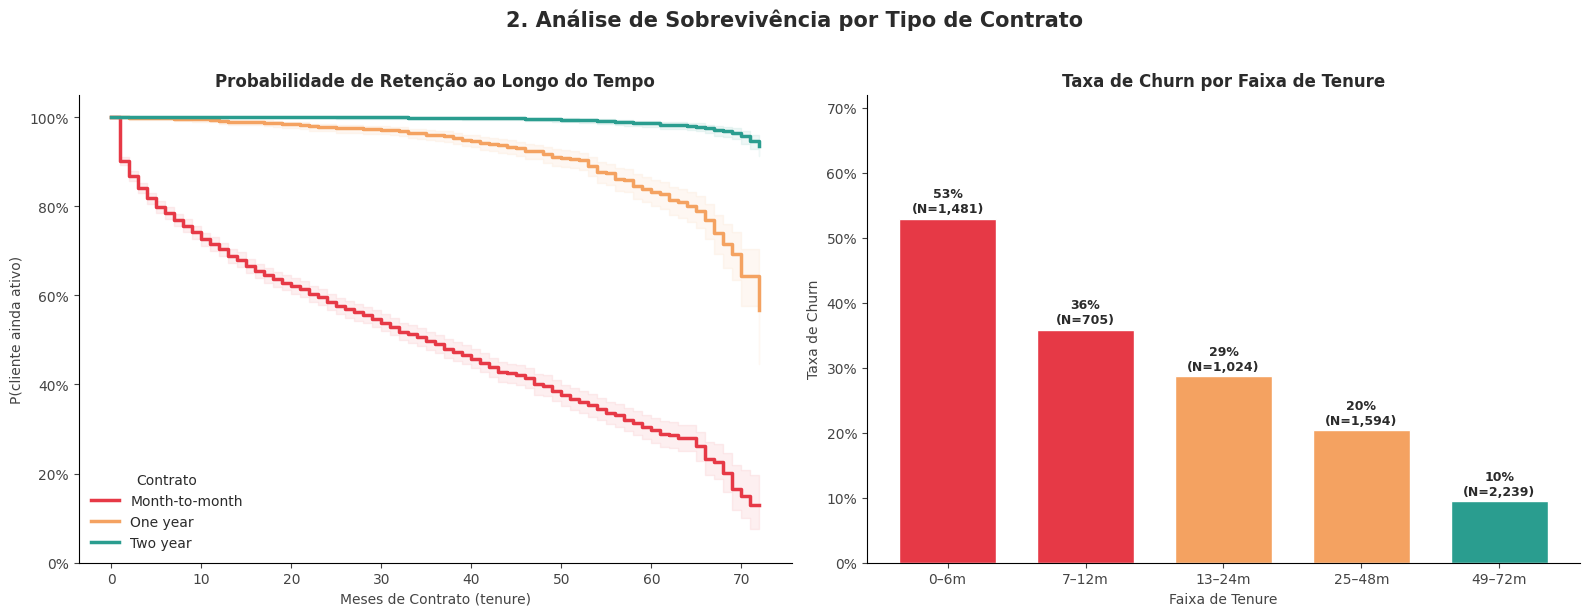

Contrato               Churn@6m  Churn@12m  Churn@24m    Mediana
--------------------------------------------------------------
Month-to-month            21.4%      29.7%      41.4%        35m
One year                   0.3%       0.9%       2.2%     > base
Two year                   0.0%       0.0%       0.0%     > base


In [55]:
# KM por tipo de contrato
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('2. Análise de Sobrevivência por Tipo de Contrato', fontsize=15, fontweight='bold', y=1.02)

cores_ct  = {'Month-to-month': COR_CHURN, 'One year': COR_WARN, 'Two year': COR_RETIDO}
km_results = {}

for contract, cor in cores_ct.items():
    sub = df[df['Contract'] == contract]
    kmf = KaplanMeierFitter()
    kmf.fit(sub['tenure'], event_observed=sub['y'], label=contract)
    km_results[contract] = kmf
    kmf.plot_survival_function(ax=axes[0], color=cor, linewidth=2.5, ci_alpha=0.08)

axes[0].set_title('Probabilidade de Retenção ao Longo do Tempo', fontweight='bold')
axes[0].set_xlabel('Meses de Contrato (tenure)')
axes[0].set_ylabel('P(cliente ainda ativo)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.05)
axes[0].legend(title='Contrato', frameon=False)
sns.despine(ax=axes[0])

# Taxa de churn por faixa de tenure
tenure_stats = df.groupby('tenure_faixa', observed=True).agg(
    n          = ('y', 'count'),
    churners   = ('y', 'sum'),
    churn_rate = ('y', 'mean')
).reset_index()

cores_faixa = [COR_CHURN if r > 0.35 else COR_WARN if r > 0.20 else COR_RETIDO
               for r in tenure_stats['churn_rate']]
bars = axes[1].bar(tenure_stats['tenure_faixa'], tenure_stats['churn_rate'],
                   color=cores_faixa, edgecolor='white', width=0.7)
axes[1].set_title('Taxa de Churn por Faixa de Tenure', fontweight='bold')
axes[1].set_xlabel('Faixa de Tenure')
axes[1].set_ylabel('Taxa de Churn')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, 0.72)
for b, row in zip(bars, tenure_stats.itertuples()):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{row.churn_rate:.0%}\n(N={row.n:,})',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Tabela KM em pontos-chave — churn acumulado─
print(f"{'Contrato':<20} {'Churn@6m':>10} {'Churn@12m':>10} {'Churn@24m':>10} {'Mediana':>10}")
print("-" * 62)
for ct, kmf in km_results.items():
    c6  = 1 - kmf.survival_function_at_times([6]).values[0]
    c12 = 1 - kmf.survival_function_at_times([12]).values[0]
    c24 = 1 - kmf.survival_function_at_times([24]).values[0]
    med = kmf.median_survival_time_
    med_str = f"{med:.0f}m" if med < np.inf else "> base"
    print(f"{ct:<20} {c6:>10.1%} {c12:>10.1%} {c24:>10.1%} {med_str:>10}")


- **1 em cada 3 clientes M2M cancela antes de completar 12 meses.** O risco é máximo nos primeiros 6 meses (52,9% de churn na faixa 0–6m) e cai monotonicamente com o tempo.
- Contratos anuais e bianuais têm sobrevivência de 99%+ em 12 meses — **o produto funciona quando há comprometimento contratual.** O problema não é o produto; é o modelo comercial M2M sem mecanismo de fidelização.
- Quem sobrevive ao primeiro ano no M2M tem probabilidade muito menor de sair — a **janela crítica de intervenção é os primeiros 12 meses.**


---
## 3. Perfil dos churners
*Testes qui-quadrado confirmam que todas as diferenças abaixo são estatisticamente significativas (p < 0,001).*


In [56]:
def chi2_str(var, vals=None):
    """Retorna string com chi2 e p-valor para uma variável categórica vs churn."""
    sub = df if vals is None else df[df[var].isin(vals)]
    ct  = pd.crosstab(sub[var], sub['y'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    return f"χ²={chi2:.0f}, p={p:.1e} {sig}"

print("Contrato     :", chi2_str('Contract'))
print("Internet     :", chi2_str('InternetService'))
print("Pagamento    :", chi2_str('PaymentMethod'))
print("SeniorCitizen:", chi2_str('SeniorCitizen'))
print("Paperless    :", chi2_str('PaperlessBilling'))


Contrato     : χ²=1185, p=5.9e-258 ***
Internet     : χ²=732, p=9.6e-160 ***
Pagamento    : χ²=648, p=3.7e-140 ***
SeniorCitizen: χ²=159, p=1.5e-36 ***
Paperless    : χ²=258, p=4.1e-58 ***


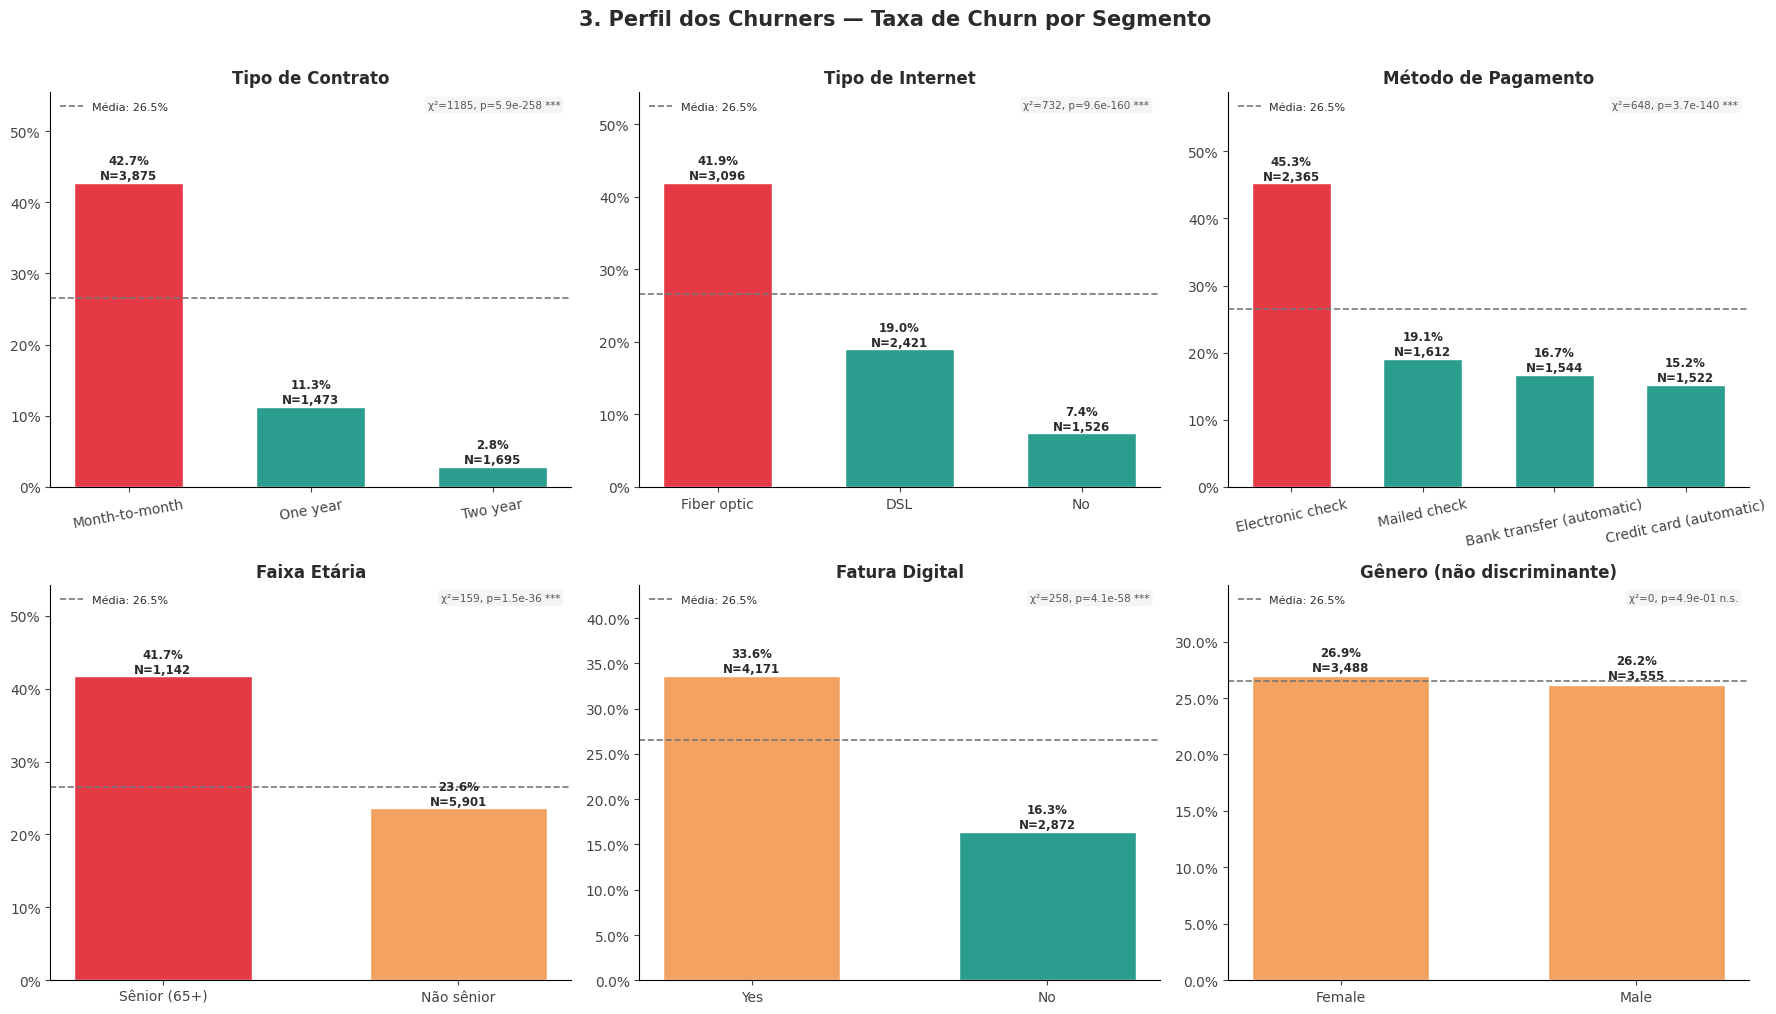

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('3. Perfil dos Churners — Taxa de Churn por Segmento', fontsize=15, fontweight='bold', y=1.01)

LINHA_MEDIA = df['y'].mean()

def plot_bar(ax, series_grp, title, chi2_label, rotate=0):
    stats = df.groupby(series_grp)['y'].agg(churn_rate='mean', n='count').reset_index()
    stats = stats.sort_values('churn_rate', ascending=False).reset_index(drop=True)
    cores = [COR_CHURN if r > 0.35 else COR_WARN if r > 0.20 else COR_RETIDO
             for r in stats['churn_rate']]
    bars = ax.bar(stats[series_grp], stats['churn_rate'], color=cores, edgecolor='white', width=0.6)
    ax.axhline(LINHA_MEDIA, color='#777', linestyle='--', linewidth=1.2, label=f'Média: {LINHA_MEDIA:.1%}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, stats['churn_rate'].max() * 1.30)
    ax.tick_params(axis='x', rotation=rotate)
    ax.legend(fontsize=8, frameon=False)
    for b, row in zip(bars, stats.itertuples()):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{row.churn_rate:.1%}\nN={row.n:,}', ha='center', fontsize=8.5, fontweight='bold')
    ax.text(0.98, 0.98, chi2_label, transform=ax.transAxes,
            fontsize=7.5, ha='right', va='top', color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', edgecolor='none'))

plot_bar(axes[0,0], 'Contract',        'Tipo de Contrato',       chi2_str('Contract'),       rotate=10)
plot_bar(axes[0,1], 'InternetService', 'Tipo de Internet',        chi2_str('InternetService'))
plot_bar(axes[0,2], 'PaymentMethod',   'Método de Pagamento',     chi2_str('PaymentMethod'),  rotate=12)

# SeniorCitizen com labels legíveis
df['Senior_label'] = df['SeniorCitizen'].map({0: 'Não sênior', 1: 'Sênior (65+)'})
plot_bar(axes[1,0], 'Senior_label',      'Faixa Etária',           chi2_str('SeniorCitizen'))

plot_bar(axes[1,1], 'PaperlessBilling', 'Fatura Digital',          chi2_str('PaperlessBilling'))

# Gênero — mostrar como não discriminante
plot_bar(axes[1,2], 'gender',           'Gênero (não discriminante)', chi2_str('gender'))

plt.tight_layout()
plt.show()


**Cada associação é estatisticamente significativa (p < 0,001), exceto gênero**

**Caveat (Electronic Check e Paperless):** associação não implica causalidade. Esses atributos podem ser *consequência* da decisão de sair (cliente migra para pagamento manual para facilitar o cancelamento), não a *causa*. Em ambos os casos, a intervenção é a mesma: tratar como **sinal de alerta no CRM**.


---
## 4. O que *realmente* importa?

O modelo XGBoost é treinado aqui **exclusivamente para extrair a importância das variáveis** (valores SHAP). Isso responde: *"de todas as 13 variáveis disponíveis, quais explicam mais o churn, e em que direção?"*

**Nota:** `TotalCharges` foi excluída do modelo pois é derivada de `tenure × MonthlyCharges`. Incluí-la causaria *data leakage* e inflaria artificialmente a importância de uma variável que não seria disponível para novos clientes.


In [68]:
FEATURES = ['Contract', 'InternetService', 'tenure', 'PaymentMethod',
            'n_services', 'MonthlyCharges', 'SeniorCitizen', 'TechSupport',
            'OnlineSecurity', 'PaperlessBilling', 'Partner', 'Dependents',
            'PhoneService']

df_model = df[FEATURES + ['y']].copy()

# 2. Tratamento do Target (y)
if df_model['y'].dtype == 'object':
    df_model['y'] = df_model['y'].map({'No': 0, 'Yes': 1})

# 3. Tratamento das Categóricas (One-Hot Encoding)
categorical_cols = df_model[FEATURES].select_dtypes(include=['object']).columns
df_final = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# 4. Separação de X e y
X = df_final.drop('y', axis=1)
y = df_final['y']

# 5. Cálculo do peso para balanceamento de classes
ratio = (y == 0).sum() / (y == 1).sum()

# 6. Configuração do Modelo XGBoost
model = xgb.XGBClassifier(
    n_estimators = 300,
    max_depth = 4,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = ratio, # Aplica o balanceamento
    eval_metric = 'auc',
    random_state = 42,
    verbosity = 0
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores   = []
shap_oof     = np.zeros(X.shape)   # acumula SHAP de cada fold

for fold, (train_idx, test_idx) in enumerate(cv_strategy.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_fold = xgb.XGBClassifier(
        n_estimators      = 300,
        max_depth         = 4,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = (y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric       = 'auc',
        random_state      = 42,
        verbosity         = 0
    )
    model_fold.fit(X_train, y_train)

    # AUC no fold de teste
    from sklearn.metrics import roc_auc_score
    preds = model_fold.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, preds))

    explainer_fold            = shap.TreeExplainer(model_fold)
    shap_oof[test_idx]        = explainer_fold.shap_values(X_test)

auc_cv = np.mean(auc_scores)
print(f"ROC-AUC (5-fold CV out-of-fold): {auc_cv:.3f}  ±{np.std(auc_scores):.3f}")
print(f"Total de colunas após Encoding : {X.shape[1]}")

shap_values = shap_oof

model.fit(X, y)

# 8. Output Final Formatado
print(f"ROC-AUC (5-fold CV com Shuffle): {auc_cv:.3f}")
print(f"Total de colunas após Encoding: {X.shape[1]}")

ROC-AUC (5-fold CV out-of-fold): 0.841  ±0.003
Total de colunas após Encoding : 19
ROC-AUC (5-fold CV com Shuffle): 0.841
Total de colunas após Encoding: 19


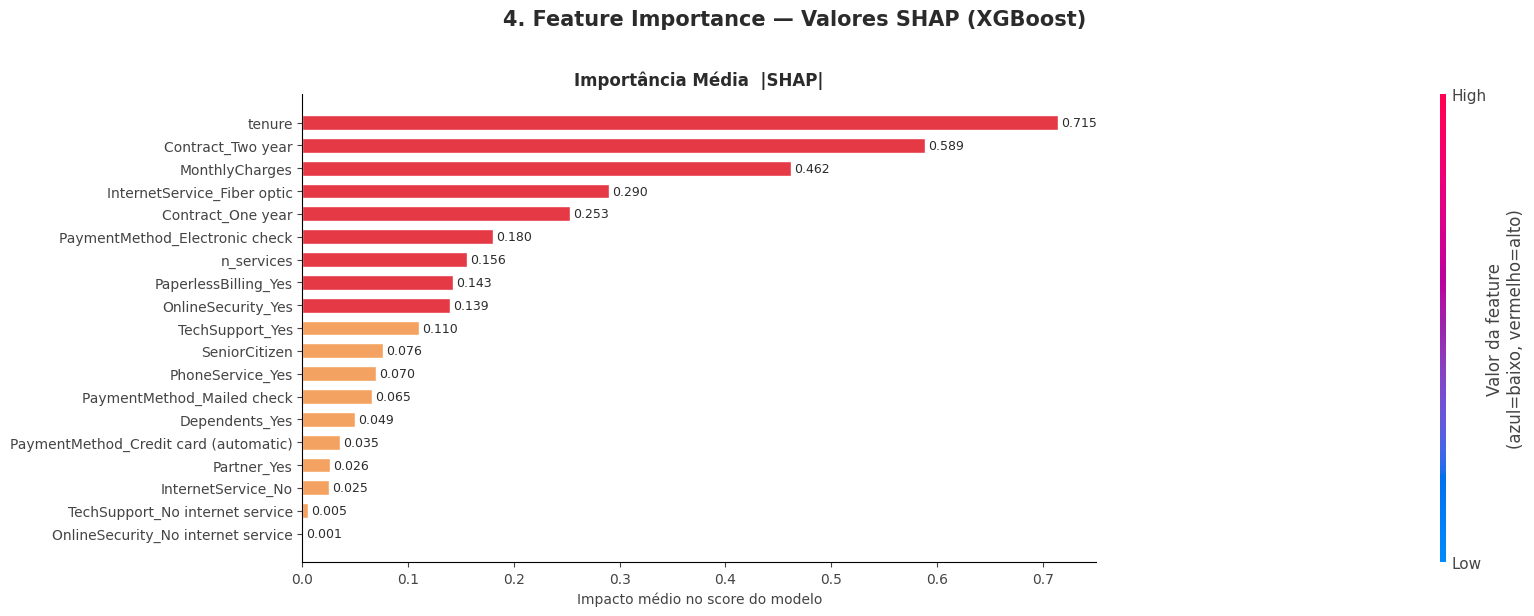

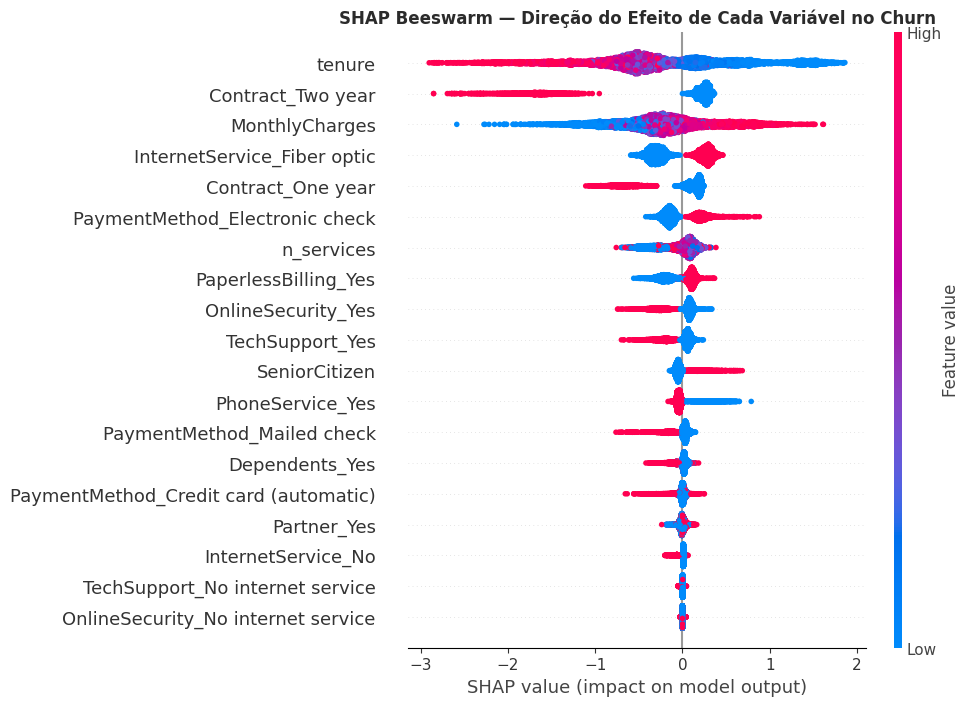

In [69]:
# SHAP: importância global
mean_shap = pd.Series(np.abs(shap_values).mean(0), index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4. Feature Importance — Valores SHAP (XGBoost)', fontsize=15, fontweight='bold', y=1.02)

# 4a — Importância global (mean |SHAP|)
colors_shap = [COR_CHURN if v > mean_shap.median() else COR_WARN
               for v in mean_shap.values]
axes[0].barh(mean_shap.index, mean_shap.values, color=colors_shap, edgecolor='white', height=0.65)
axes[0].set_title('Importância Média  |SHAP|', fontweight='bold')
axes[0].set_xlabel('Impacto médio no score do modelo')
for i, (feat, val) in enumerate(mean_shap.items()):
    axes[0].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

# 4b — Beeswarm: direção do efeito
shap.summary_plot(shap_values, X, feature_names=X.columns,
                  plot_type='dot', show=False, plot_size=None,
                  color_bar_label='Valor da feature\n(azul=baixo, vermelho=alto)')
ax_shap = plt.gca()
ax_shap.set_title('Direção do Efeito (beeswarm)', fontweight='bold')

plt.sca(axes[1])
plt.axis('off')
axes[1].set_visible(False)

plt.tight_layout()
plt.show()

# Beeswarm separado para clareza
fig2, ax2 = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X, feature_names=X.columns, show=False, plot_size=None)

ax2.set_title('SHAP Beeswarm — Direção do Efeito de Cada Variável no Churn',
              fontweight='bold', fontsize=12)
plt.show()


In [60]:
shap_df = pd.Series(np.abs(shap_values).mean(0), index=X.columns) \
            .sort_values(ascending=False) \
            .reset_index()

shap_df.columns = ['Feature', 'Mean |SHAP|']
shap_df['Rank'] = range(1, len(shap_df)+1)

# Calculando a importância acumulada
shap_df['% importância acum.'] = (shap_df['Mean |SHAP|'].cumsum() /
                                   shap_df['Mean |SHAP|'].sum() * 100).round(1)

print(shap_df[['Rank', 'Feature', 'Mean |SHAP|', '% importância acum.']].to_string(index=False))

 Rank                               Feature  Mean |SHAP|  % importância acum.
    1                                tenure     0.710179            21.100000
    2                     Contract_Two year     0.582203            38.299999
    3                        MonthlyCharges     0.471899            52.299999
    4           InternetService_Fiber optic     0.282236            60.700001
    5                     Contract_One year     0.246125            68.000000
    6        PaymentMethod_Electronic check     0.179828            73.300003
    7                            n_services     0.172685            78.500000
    8                  PaperlessBilling_Yes     0.137917            82.599998
    9                    OnlineSecurity_Yes     0.134243            86.500000
   10                       TechSupport_Yes     0.118703            90.099998
   11            PaymentMethod_Mailed check     0.075840            92.300003
   12                      PhoneService_Yes     0.073805        


**Partner e PhoneService** têm SHAP próximo de zero — variáveis não preditivas neste dataset.


---
## 5. Segmento crítico: onde o problema se concentra?

Cruzando as variáveis de maior importância (SHAP), chegamos ao segmento de maior risco absoluto.


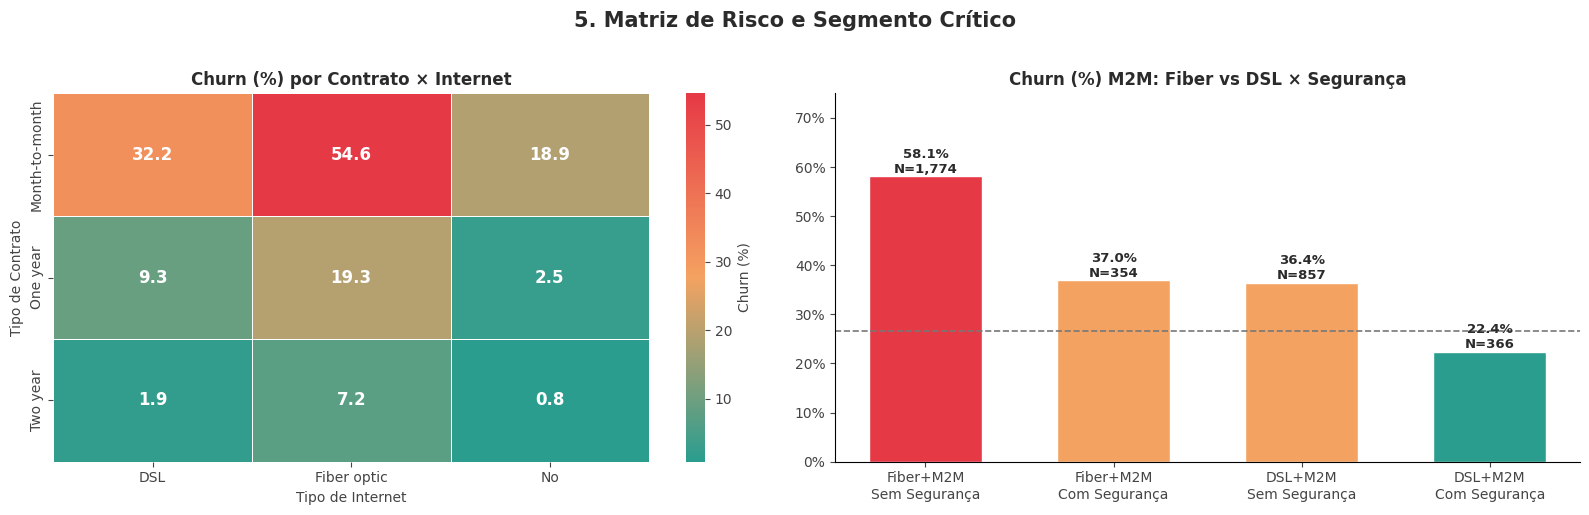

In [61]:
# Heatmap: Contrato × Internet─
pivot = df.pivot_table(values='y', index='Contract',
                       columns='InternetService', aggfunc='mean') * 100
pivot = pivot.reindex(['Month-to-month', 'One year', 'Two year'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('5. Matriz de Risco e Segmento Crítico', fontsize=15, fontweight='bold', y=1.02)

sns.heatmap(pivot, annot=True, fmt='.1f', cmap=CMAP_RISCO,
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Churn (%)'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Churn (%) por Contrato × Internet', fontweight='bold')
axes[0].set_xlabel('Tipo de Internet')
axes[0].set_ylabel('Tipo de Contrato')

# Comparação dos 4 sub-segmentos Fiber M2M por OnlineSecurity
grupos = {
    'Fiber+M2M\nSem Segurança' : df[(df['InternetService']=='Fiber optic') &
                                      (df['Contract']=='Month-to-month') &
                                      (df['OnlineSecurity']=='No')],
    'Fiber+M2M\nCom Segurança' : df[(df['InternetService']=='Fiber optic') &
                                      (df['Contract']=='Month-to-month') &
                                      (df['OnlineSecurity']=='Yes')],
    'DSL+M2M\nSem Segurança'   : df[(df['InternetService']=='DSL') &
                                      (df['Contract']=='Month-to-month') &
                                      (df['OnlineSecurity']=='No')],
    'DSL+M2M\nCom Segurança'   : df[(df['InternetService']=='DSL') &
                                      (df['Contract']=='Month-to-month') &
                                      (df['OnlineSecurity']=='Yes')],
}

nomes  = list(grupos.keys())
rates  = [g['y'].mean() for g in grupos.values()]
ns     = [len(g) for g in grupos.values()]
cores_seg = [COR_CHURN if r > 0.45 else COR_WARN if r > 0.30 else COR_RETIDO for r in rates]

bars = axes[1].bar(nomes, rates, color=cores_seg, edgecolor='white', width=0.6)
axes[1].set_title('Churn (%) M2M: Fiber vs DSL × Segurança', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].axhline(LINHA_MEDIA, color='#777', linestyle='--', linewidth=1.2)
axes[1].set_ylim(0, 0.75)
for b, r, n in zip(bars, rates, ns):
    axes[1].text(b.get_x() + b.get_width()/2, r + 0.007,
                 f'{r:.1%}\nN={n:,}', ha='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()


In [62]:
# Tabela do segmento central
seg_central = df[(df['InternetService']=='Fiber optic') &
                  (df['Contract']=='Month-to-month') &
                  (df['OnlineSecurity']=='No')]

n_seg        = len(seg_central)
churn_seg    = seg_central['y'].mean()
arpu_seg     = seg_central['MonthlyCharges'].mean()
mrr_seg      = seg_central[seg_central['y']==1]['MonthlyCharges'].sum()
pct_churners = seg_central['y'].sum() / n_churn

print(f"  N              : {n_seg:,} clientes")
print(f"  Churn          : {churn_seg:.1%}")
print(f"  ARPU           : R$ {arpu_seg:.2f}/mês")
print(f"  MRR em risco   : R$ {mrr_seg:,.0f}/mês")
print(f"  % total churn  : {pct_churners:.1%}")
print()

  N              : 1,774 clientes
  Churn          : 58.1%
  ARPU           : R$ 85.96/mês
  MRR em risco   : R$ 88,352/mês
  % total churn  : 55.2%



**SEGMENTO CRÍTICO: Fiber + M2M + Sem OnlineSecurity**

In [63]:
# Efeito independente dos dois fatores
fiber_sem = df[(df['InternetService']=='Fiber optic') & (df['Contract']=='Month-to-month') & (df['OnlineSecurity']=='No')]['y'].mean()
fiber_com = df[(df['InternetService']=='Fiber optic') & (df['Contract']=='Month-to-month') & (df['OnlineSecurity']=='Yes')]['y'].mean()
dsl_sem   = df[(df['InternetService']=='DSL')         & (df['Contract']=='Month-to-month') & (df['OnlineSecurity']=='No')]['y'].mean()
dsl_com   = df[(df['InternetService']=='DSL')         & (df['Contract']=='Month-to-month') & (df['OnlineSecurity']=='Yes')]['y'].mean()

print(f"  Fiber: {fiber_sem:.1%} → {fiber_com:.1%}  (gap: {fiber_sem-fiber_com:.1%})")
print(f"  DSL  : {dsl_sem:.1%}  → {dsl_com:.1%}   (gap: {dsl_sem-dsl_com:.1%})")

  Fiber: 58.1% → 37.0%  (gap: 21.1%)
  DSL  : 36.4%  → 22.4%   (gap: 14.0%)


* OnlineSecurity tem efeito independente e consistente nos dois tipos de internet.
* Os fatores **Fiber (Fibra)** e a **ausência de OnlineSecurity** são aditivos. Ou seja, um não justifica o outro; ambos contribuem separadamente para o aumento da rotatividade.

Existe uma lacuna crítica que a base de dados atual não consegue preencher:
**Por que a Fibra mantém um Churn 15–22 p.p. acima do DSL, mesmo quando o OnlineSecurity está contratado?**

Para entender a causa raiz, precisamos de **dados externos** ou novas variáveis.

---
## 6. Alavancas de intervenção

Três ações derivam diretamente dos padrões identificados. Impactos são **estimativas associativas** — requerem A/B test para validação.


In [64]:
# Alavanca 1: OnlineSecurity no onboarding Fiber M2M─
seg1_sem = seg_central
seg1_com = df[(df['InternetService']=='Fiber optic') &
               (df['Contract']=='Month-to-month') &
               (df['OnlineSecurity']=='Yes')]

delta_1    = seg1_sem['y'].mean() - seg1_com['y'].mean()   # 21,1 pp observados
n_hipot_1  = n_seg * delta_1
mrr_hip_1  = n_hipot_1 * arpu_seg

# Alavanca 2: Gatilho CRM — Electronic check M2M─
seg2       = df[(df['Contract']=='Month-to-month') &
                 (df['PaymentMethod']=='Electronic check')]
auto_m2m   = df[(df['Contract']=='Month-to-month') &
                 (df['PaymentMethod'].isin(['Bank transfer (automatic)',
                                            'Credit card (automatic)']))]
delta_2    = seg2['y'].mean() - auto_m2m['y'].mean()
mrr_risco2 = seg2[seg2['y']==0]['MonthlyCharges'].sum()

# Alavanca 3: Oferta de migração M2M → Anual, janela 8–10m─
seg3_m2m    = df[(df['Contract']=='Month-to-month') & (df['tenure'].between(8,10))]
seg3_anual  = df[(df['Contract']=='One year')        & (df['tenure'].between(8,10))]
delta_3     = seg3_m2m['y'].mean() - seg3_anual['y'].mean()
mrr_risco3 = seg3_m2m[seg3_m2m['y']==0]['MonthlyCharges'].sum()

print("ALAVANCA 1  OnlineSecurity no onboarding — Fiber M2M")
print(f"  Segmento   : {n_seg:,} clientes Fiber + M2M + Sem Segurança")
print(f"  Churn atual: {seg1_sem['y'].mean():.1%}  |  Churn no grupo com segurança: {seg1_com['y'].mean():.1%}")
print(f"  Delta obs. : {delta_1:.1%}")
print(f"  Hipótese   : se o delta se confirmar no A/B → ~{n_hipot_1:.0f} clientes retidos")
print(f"  MRR poten. : R$ {mrr_hip_1:,.0f}/mês")
print(f"  Ação       : incluir OnlineSecurity como padrão no onboarding Fiber M2M")
print(f"  Validação  : A/B test — metade dos novos Fiber M2M recebe segurança grátis por 3m")
print()
print("─" * 70)
print("ALAVANCA 2  Electronic check como gatilho de CRM")
print(f"  Segmento   : {len(seg2):,} clientes M2M em electronic check")
print(f"  Churn      : {seg2['y'].mean():.1%}  vs  {auto_m2m['y'].mean():.1%} nos automáticos (M2M)")
print(f"  Delta obs. : {delta_2:.1%}")
print(f"  MRR risco  : R$ {mrr_risco2:,.0f}/mês")
print(f"  Ação       : ativar régua de retenção proativa para M2M em e-check")
print(f"  Nota       : causalidade incerta — tratar como sinal, não como causa")
print()
print("─" * 70)
print("ALAVANCA 3  Oferta de migração M2M → Anual na janela 8–10 meses")
print(f"  Segmento   : {len(seg3_m2m):,} clientes M2M com tenure 8–10m")
print(f"  Churn M2M  : {seg3_m2m['y'].mean():.1%}  |  Churn anual (8–10m): {seg3_anual['y'].mean():.1%}")
print(f"  Delta obs. : {delta_3:.1%}")
print(f"  MRR risco  : R$ {mrr_risco3:,.0f}/mês")
print(f"  Racional   : janela pós-período inicial de risco, pré-platô de retenção")
print(f"  Ação       : oferta ativa de upgrade contratual com incentivo a definir")


ALAVANCA 1  OnlineSecurity no onboarding — Fiber M2M
  Segmento   : 1,774 clientes Fiber + M2M + Sem Segurança
  Churn atual: 58.1%  |  Churn no grupo com segurança: 37.0%
  Delta obs. : 21.1%
  Hipótese   : se o delta se confirmar no A/B → ~375 clientes retidos
  MRR poten. : R$ 32,193/mês
  Ação       : incluir OnlineSecurity como padrão no onboarding Fiber M2M
  Validação  : A/B test — metade dos novos Fiber M2M recebe segurança grátis por 3m

──────────────────────────────────────────────────────────────────────
ALAVANCA 2  Electronic check como gatilho de CRM
  Segmento   : 1,850 clientes M2M em electronic check
  Churn      : 53.7%  vs  33.5% nos automáticos (M2M)
  Delta obs. : 20.2%
  MRR risco  : R$ 77,316/mês
  Ação       : ativar régua de retenção proativa para M2M em e-check
  Nota       : causalidade incerta — tratar como sinal, não como causa

──────────────────────────────────────────────────────────────────────
ALAVANCA 3  Oferta de migração M2M → Anual na janela 8–10 m

In [65]:
# Tabela de priorização final─
prio = pd.DataFrame([
    {'#': 1,
     'Segmento'       : 'Fiber + M2M + Sem OnlineSecurity',
     'N'              : f'{n_seg:,}',
     'Churn atual'    : f'{seg1_sem["y"].mean():.1%}',
     'MRR em risco'   : f'R${mrr_seg:,.0f}/mês',
     '% churn total'  : f'{pct_churners:.1%}',
     'Ação'           : 'OnlineSecurity no onboarding',
     'Teste'          : 'A/B 3 meses'},
    {'#': 2,
     'Segmento'       : 'M2M + Electronic check',
     'N'              : f'{len(seg2):,}',
     'Churn atual'    : f'{seg2["y"].mean():.1%}',
     'MRR em risco'   : f'R${mrr_risco2:,.0f}/mês',
     '% churn total'  : f'{seg2[seg2["y"]==1]["y"].sum()/n_churn:.1%}',
     'Ação'           : 'Gatilho CRM proativo',
     'Teste'          : 'Holdout controlado'},
    {'#': 3,
     'Segmento'       : 'M2M tenure 8–10m',
     'N'              : f'{len(seg3_m2m):,}',
     'Churn atual'    : f'{seg3_m2m["y"].mean():.1%}',
     'MRR em risco'   : f'R${mrr_risco3:,.0f}/mês',
     '% churn total'  : f'{seg3_m2m[seg3_m2m["y"]==1]["y"].sum()/n_churn:.1%}',
     'Ação'           : 'Oferta migração para anual',
     'Teste'          : 'A/B 6 meses'},
])

pd.set_option('display.max_colwidth', 40)
print(prio.to_string(index=False))


 #                         Segmento     N Churn atual MRR em risco % churn total                         Ação              Teste
 1 Fiber + M2M + Sem OnlineSecurity 1,774       58.1% R$88,352/mês         55.2% OnlineSecurity no onboarding        A/B 3 meses
 2           M2M + Electronic check 1,850       53.7% R$77,316/mês         53.2%         Gatilho CRM proativo Holdout controlado
 3                 M2M tenure 8–10m   302       43.4%  R$9,980/mês          7.0%   Oferta migração para anual        A/B 6 meses


**Por que essa ordem?**

- **Alavanca 1** tem o maior segmento, o maior churn, a maior MRR em risco, e a hipótese mais diretamente testável. Concentra **55% de todo o churn da empresa** em um único segmento identificável no momento do onboarding.
- **Alavanca 2** tem alcance amplo (1.850 clientes) com sinal comportamental imediato no CRM. Requer pouco investimento operacional.
- **Alavanca 3** tem N menor, mas é a única intervenção que muda estruturalmente o modelo comercial — converter M2M para anual é a solução de fundo para o problema de payback.


In [67]:
# % dos churners em M2M
pct_churn_m2m = (
    df[(df['y']==1) & (df['Contract']=='Month-to-month')]['y'].count()
    / df[df['y']==1]['y'].count()
)
print(f"% churners em M2M            : {pct_churn_m2m:.1%}")

# % clientes M2M que cancelam antes de 12m
m2m_churn_12m = df[
    (df['Contract']=='Month-to-month') &
    (df['y']==1) &
    (df['tenure'] < 12)
]
m2m_total = df[df['Contract']=='Month-to-month']
print(f"Churners M2M com tenure < 12m: {len(m2m_churn_12m)/len(m2m_total):.1%} dos clientes M2M")

# segmento crítico e % do churn total
print(f"Segmento crítico N           : {n_seg:,}  |  churn: {churn_seg:.1%}")
print(f"% do churn total             : {pct_churners:.1%}")

# ratio electronic check vs débito automático
ratio_echeck = seg2['y'].mean() / auto_m2m['y'].mean()
print(f"Ratio churn e-check / auto   : {ratio_echeck:.1f}×")

# gap Fiber vs DSL (controlando por OnlineSecurity=No, M2M)
print(f"Fiber M2M sem seg.           : {fiber_sem:.1%}  |  DSL M2M sem seg.: {dsl_sem:.1%}")
print(f"Gap Fiber – DSL              : {fiber_sem - dsl_sem:.1%} p.p.")

% churners em M2M            : 88.6%
Churners M2M com tenure < 12m: 25.6% dos clientes M2M
Segmento crítico N           : 1,774  |  churn: 58.1%
% do churn total             : 55.2%
Ratio churn e-check / auto   : 1.6×
Fiber M2M sem seg.           : 58.1%  |  DSL M2M sem seg.: 36.4%
Gap Fiber – DSL              : 21.7% p.p.


---
## 7. Conclusão e Roadmap

A empresa coloca clientes de alto ticket em contratos sem fidelização (M2M), e os perde antes de amortizar o custo de setup — com pico nos primeiros 12 meses. O produto não tem defeito intrínseco (contratos anuais têm 99% de retenção em 12 meses). O problema é estrutural no modelo comercial M2M.

### Os cinco fatos que sustentam isso

1. **88,5% dos churners estão em M2M** — o tipo de contrato é o driver mais forte (SHAP #1).
2. **25,6% dos clientes M2M cancelam antes de 12 meses** — antes do payback estimado de setup.
3. O segmento **Fiber + M2M + Sem OnlineSecurity** (1.774 clientes, 58,1% de churn) concentra **55% de todo o churn da empresa**.
4. Clientes M2M em **electronic check** têm churn 1,6× maior que clientes M2M
   em débito automático — sinal comportamental utilizável no CRM hoje.
   *(Comparação controlada por tipo de contrato — M2M vs M2M)*
5. **Fiber tem churn persistentemente maior que DSL** mesmo controlando por OnlineSecurity — causa não explicada pelos dados disponíveis (lacuna a investigar).

### Roadmap

| Fase | Entregável | Prazo |
|---|---|---|
| **Imediato** | Segmentação dos 3 grupos de risco no CRM + régua de retenção para e-check M2M | 2 semanas |
| **Curto prazo** | A/B test: OnlineSecurity no onboarding Fiber M2M | 3 meses |
| **Curto prazo** | A/B test: oferta de migração para anual nos meses 8–10 | início imediato, resultado em 6m |
| **Médio prazo** | Modelo de propensão ao churn em produção (features derivadas desta EDA) | 2 meses |
| **Médio prazo** | Análise de coorte longitudinal (validar se churn está piorando ao longo do tempo) | 2 meses |
| **Contínuo** | Investigação da causa raiz do churn em Fiber: NPS + dados de tickets de suporte | ongoing |
